In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\Abha Mandar Narvekar\Downloads\archive (2).zip")

Pre-processing and Distribution 

array([5, 6, 7, 4, 8, 3], dtype=int64)

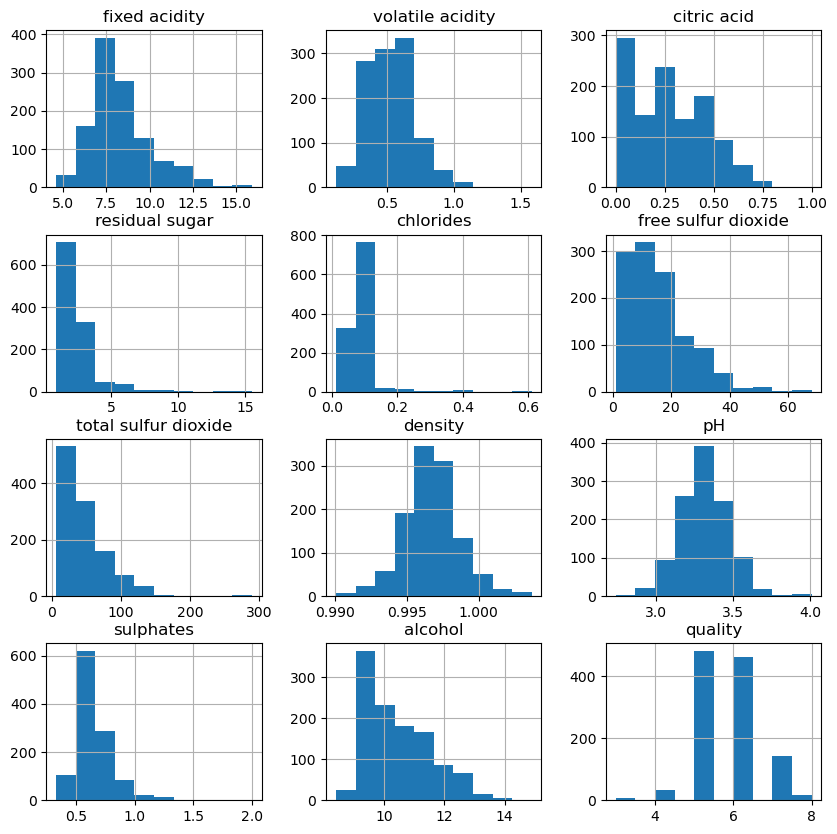

In [3]:
# First, we need to clean the data at hand
df = df.dropna(axis = 0) #dropped null values 
df = df.drop(columns = ['Id']) #dropped Id column

# Histograms 
df.hist(figsize=(10,10), grid = True)
df.describe()
df['quality'].unique()


Correlation Matrix

<Axes: >

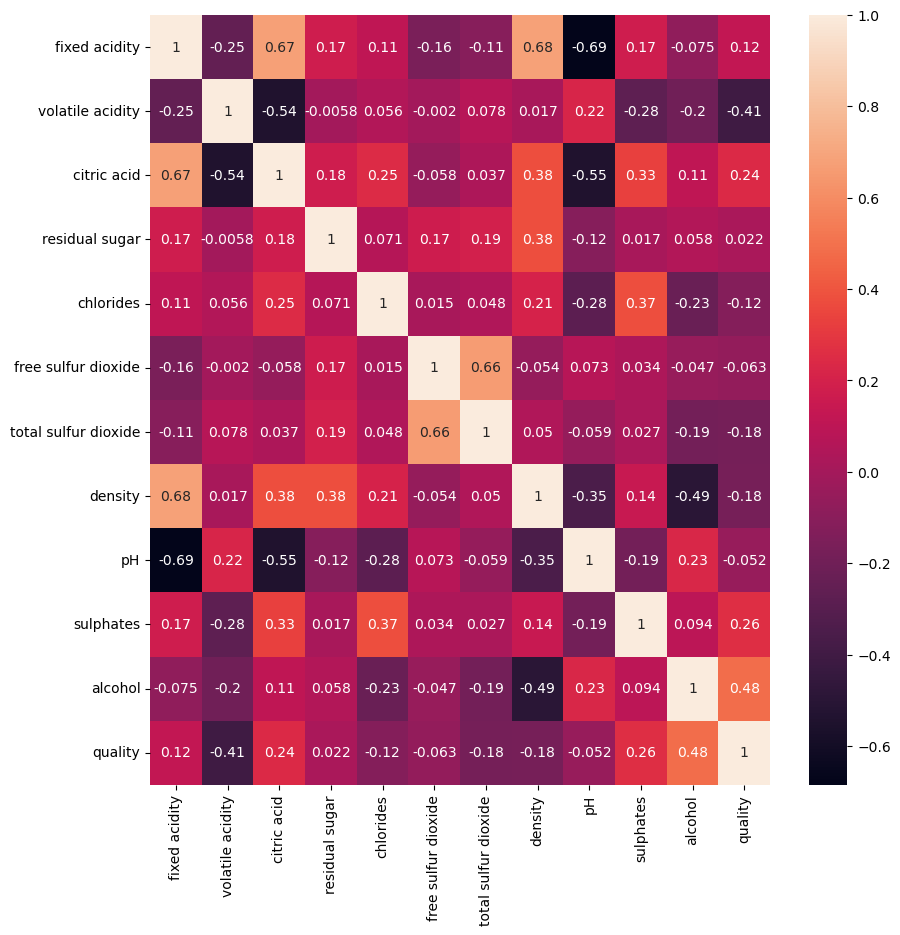

In [4]:
import seaborn as sns 
plt.figure(figsize = (10,10))
sns.heatmap (df.corr(),annot = True)

<Axes: >

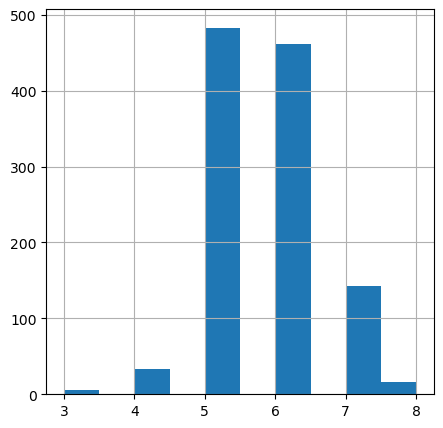

In [5]:
# Distribution of wines in the dataset
plot = plt.figure(figsize=(5,5))
df['quality'].hist(figsize = (5,5))

Binarisation of quality

In [6]:
# Quality is separated into two bins: 0, if the quality is less than 7, the wine is rated 0. Otherwise, a rating of 1 is assigned
X = df.drop(columns = ['quality'])
Y = df['quality'].apply(lambda y_value: 1 if y_value >= 7 else 0)


Using SMOTE to avoid oversampling

              precision    recall  f1-score   support

           0       0.95      0.92      0.93       197
           1       0.58      0.69      0.63        32

    accuracy                           0.89       229
   macro avg       0.76      0.80      0.78       229
weighted avg       0.90      0.89      0.89       229

AUC: 0.8911008883248732


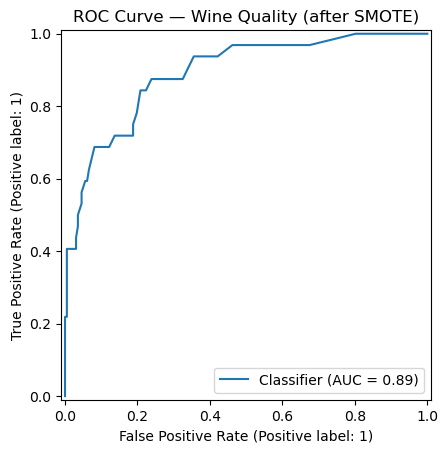

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify = Y)

from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay 

smote = SMOTE(random_state = 42)
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)


model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(x_train_res, y_train_res)

y_proba = model.predict_proba(x_test)[:,1]
y_pred = model.predict(x_test)

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_proba))

# 5. Plot ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve — Wine Quality (after SMOTE)")
plt.show()

Model Evaluation 

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, x_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()
test_accuracy = accuracy_score(x_pred, y_test)
print("Accuracy: ", test_accuracy)



Best Threshold: 0.530
Best F1: 0.629
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       197
           1       0.58      0.69      0.63        32

    accuracy                           0.89       229
   macro avg       0.76      0.80      0.78       229
weighted avg       0.90      0.89      0.89       229



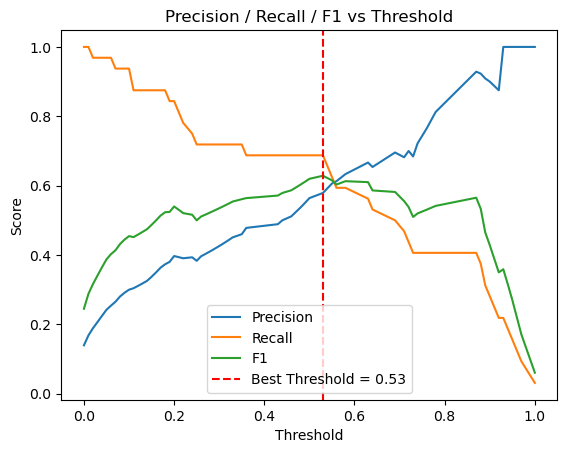

In [10]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Find threshold that maximizes F1 for class 1
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best Threshold: {best_threshold:.3f}") # upto 3 decimal places
print(f"Best F1: {f1_scores[best_idx]:.3f}") # upto 3 decimal places
y_pred_tuned = (y_proba >= best_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_tuned))

plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1_scores[:-1], label="F1")
plt.axvline(best_threshold, color='red', linestyle='--', label=f"Best Threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.legend()
plt.show()